In [16]:
import json
import os
import matplotlib.pyplot as plt

In [17]:

def plot_step1_stats(log_path, output_path):
    if not os.path.exists(log_path):
        print(f"Log file not found at {log_path}")
        return

    with open(log_path, "r") as f:
        log_data = json.load(f)

    hands = [entry["hand"] for entry in log_data]
    
    import json, os
    base_config_path = "checkpoints/base_agent_config.json"
    step1_threshold = 0.0003
    if os.path.exists(base_config_path):
        with open(base_config_path, "r") as f:
            base_config = json.load(f)
            step1_threshold = base_config.get("ppo_config", {}).get("convergence_threshold", step1_threshold)

    stats = {
        "mean_kl":     {"label": "Mean KL",     "color": "blue", "threshold": step1_threshold},
        "policy_loss": {"label": "Policy Loss", "color": "green"},
        "value_loss":  {"label": "Value Loss",  "color": "orange"},
        "entropy":     {"label": "Entropy",     "color": "purple"}
    }

    fig, axes = plt.subplots(2, 2, figsize=(15, 10))
    axes = axes.flatten()

    for i, (key, info) in enumerate(stats.items()):
        values = [entry[key] for entry in log_data]
        axes[i].plot(hands, values, label=info["label"], color=info["color"])
        axes[i].set_xlabel("Hands Played")
        axes[i].set_ylabel(info["label"])
        axes[i].set_title(f"Step 1: {info['label']} over Time")
        axes[i].grid(True)
        if "threshold" in info:
            axes[i].axhline(y=info["threshold"], color='r', linestyle='--', label=f"Threshold ({info['threshold']})")
            axes[i].legend()

    plt.tight_layout()
    plt.savefig(output_path)
    print(f"Plot saved to {output_path}")


LOG_FILE = "checkpoints/base_training_log.json"
OUTPUT_FILE = "figs/step1_training_stats.png"
plot_step1_stats(LOG_FILE, OUTPUT_FILE)
plt.show()



UnboundLocalError: cannot access local variable 'os' where it is not associated with a value

In [ ]:
import math
import matplotlib.pyplot as plt

def moving_average(values, window):
    if window <= 1:
        return [v if isinstance(v, (int, float)) and math.isfinite(v) else float("nan") for v in values]

    ma = []
    window_vals = []
    running_sum = 0.0
    running_count = 0

    for v in values:
        if isinstance(v, (int, float)) and math.isfinite(v):
            current = float(v)
            running_sum += current
            running_count += 1
        else:
            current = None

        window_vals.append(current)
        if len(window_vals) > window:
            old = window_vals.pop(0)
            if old is not None:
                running_sum -= old
                running_count -= 1

        ma.append(running_sum / running_count if running_count > 0 else float("nan"))

    return ma

Plot saved to figs/step1_training_stats_ma.png


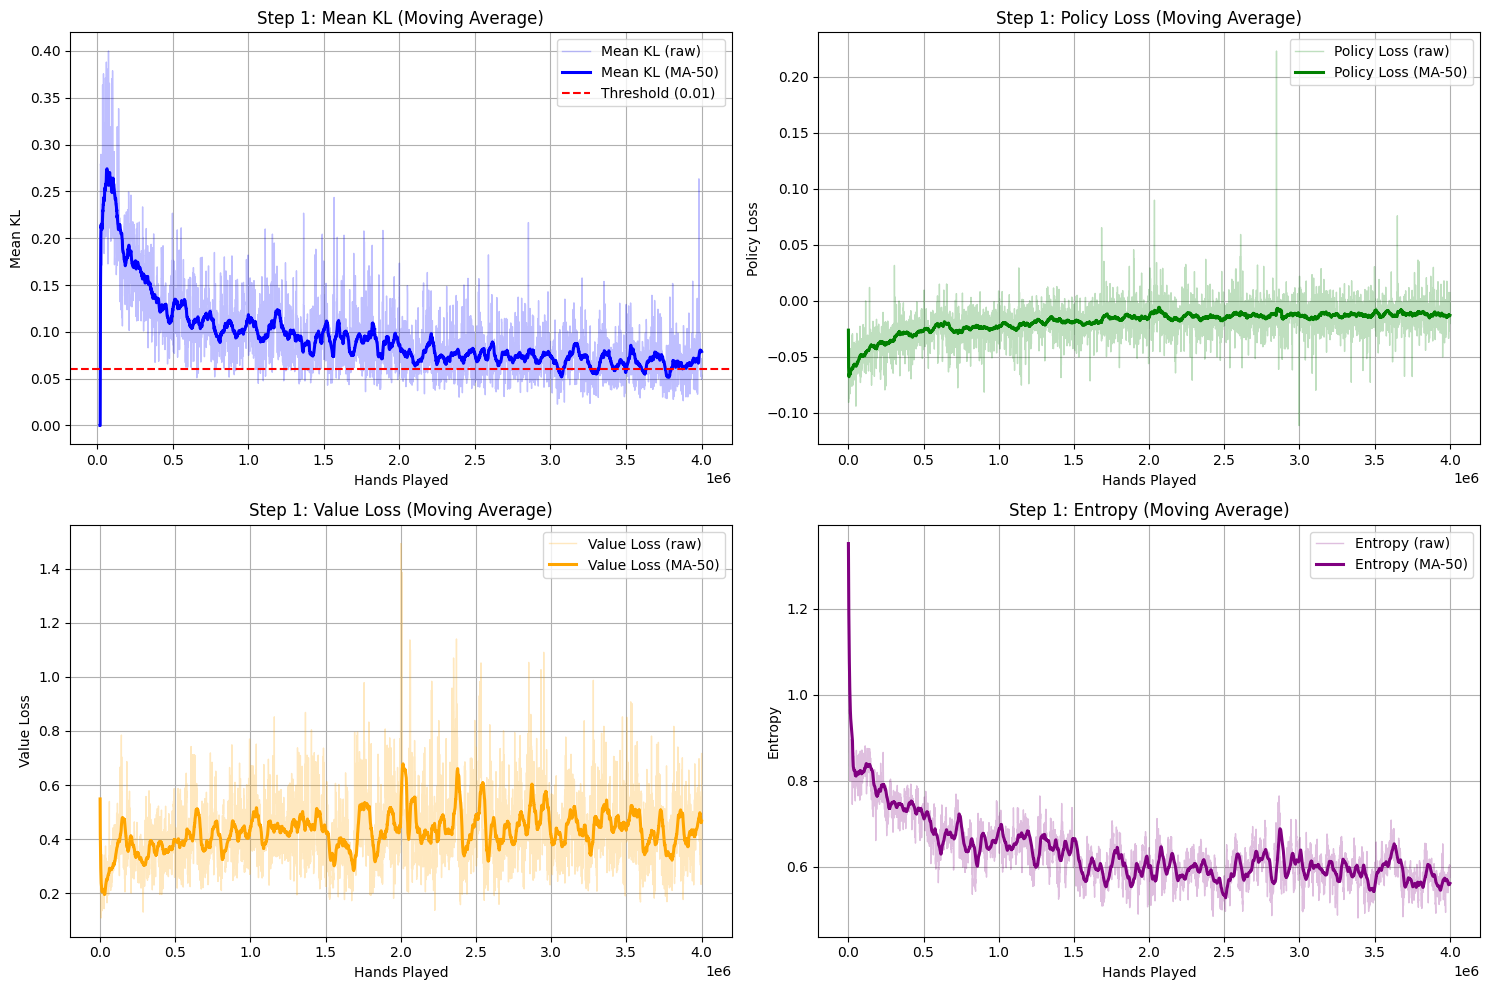

In [ ]:

def plot_step1_stats(log_path, output_path, ma_window=50, show_raw=True):
    if not os.path.exists(log_path):
        print(f"Log file not found at {log_path}")
        return

    with open(log_path, "r") as f:
        log_data = json.load(f)

    hands = [entry["hand"] for entry in log_data]

    import json, os
    base_config_path = "checkpoints/base_agent_config.json"
    step1_threshold = 0.0003
    if os.path.exists(base_config_path):
        with open(base_config_path, "r") as f:
            base_config = json.load(f)
            step1_threshold = base_config.get("ppo_config", {}).get("convergence_threshold", step1_threshold)

    stats = {
        "mean_kl":     {"label": "Mean KL",     "color": "blue",   "threshold": step1_threshold},
        "policy_loss": {"label": "Policy Loss", "color": "green"},
        "value_loss":  {"label": "Value Loss",  "color": "orange"},
        "entropy":     {"label": "Entropy",     "color": "purple"}
    }

    fig, axes = plt.subplots(2, 2, figsize=(15, 10))
    axes = axes.flatten()

    for i, (key, info) in enumerate(stats.items()):
        values = [entry[key] for entry in log_data]
        ma_values = moving_average(values, ma_window)

        if show_raw:
            axes[i].plot(
                hands, values,
                color=info["color"],
                alpha=0.25,
                linewidth=1,
                label=f"{info['label']} (raw)"
            )

        axes[i].plot(
            hands, ma_values,
            color=info["color"],
            linewidth=2.2,
            label=f"{info['label']} (MA-{ma_window})"
        )

        axes[i].set_xlabel("Hands Played")
        axes[i].set_ylabel(info["label"])
        axes[i].set_title(f"Step 1: {info['label']} (Moving Average)")
        axes[i].grid(True)

        if "threshold" in info:
            axes[i].axhline(
                y=0.06,
                color="red",
                linestyle="--",
                linewidth=1.5,
                label=f"Threshold ({info['threshold']})"
            )

        axes[i].legend()

    plt.tight_layout()
    plt.savefig(output_path, dpi=150)
    print(f"Plot saved to {output_path}")

LOG_FILE = "checkpoints/base_training_log.json"
OUTPUT_FILE = "figs/step1_training_stats_ma.png"
plot_step1_stats(LOG_FILE, OUTPUT_FILE)
plt.show()

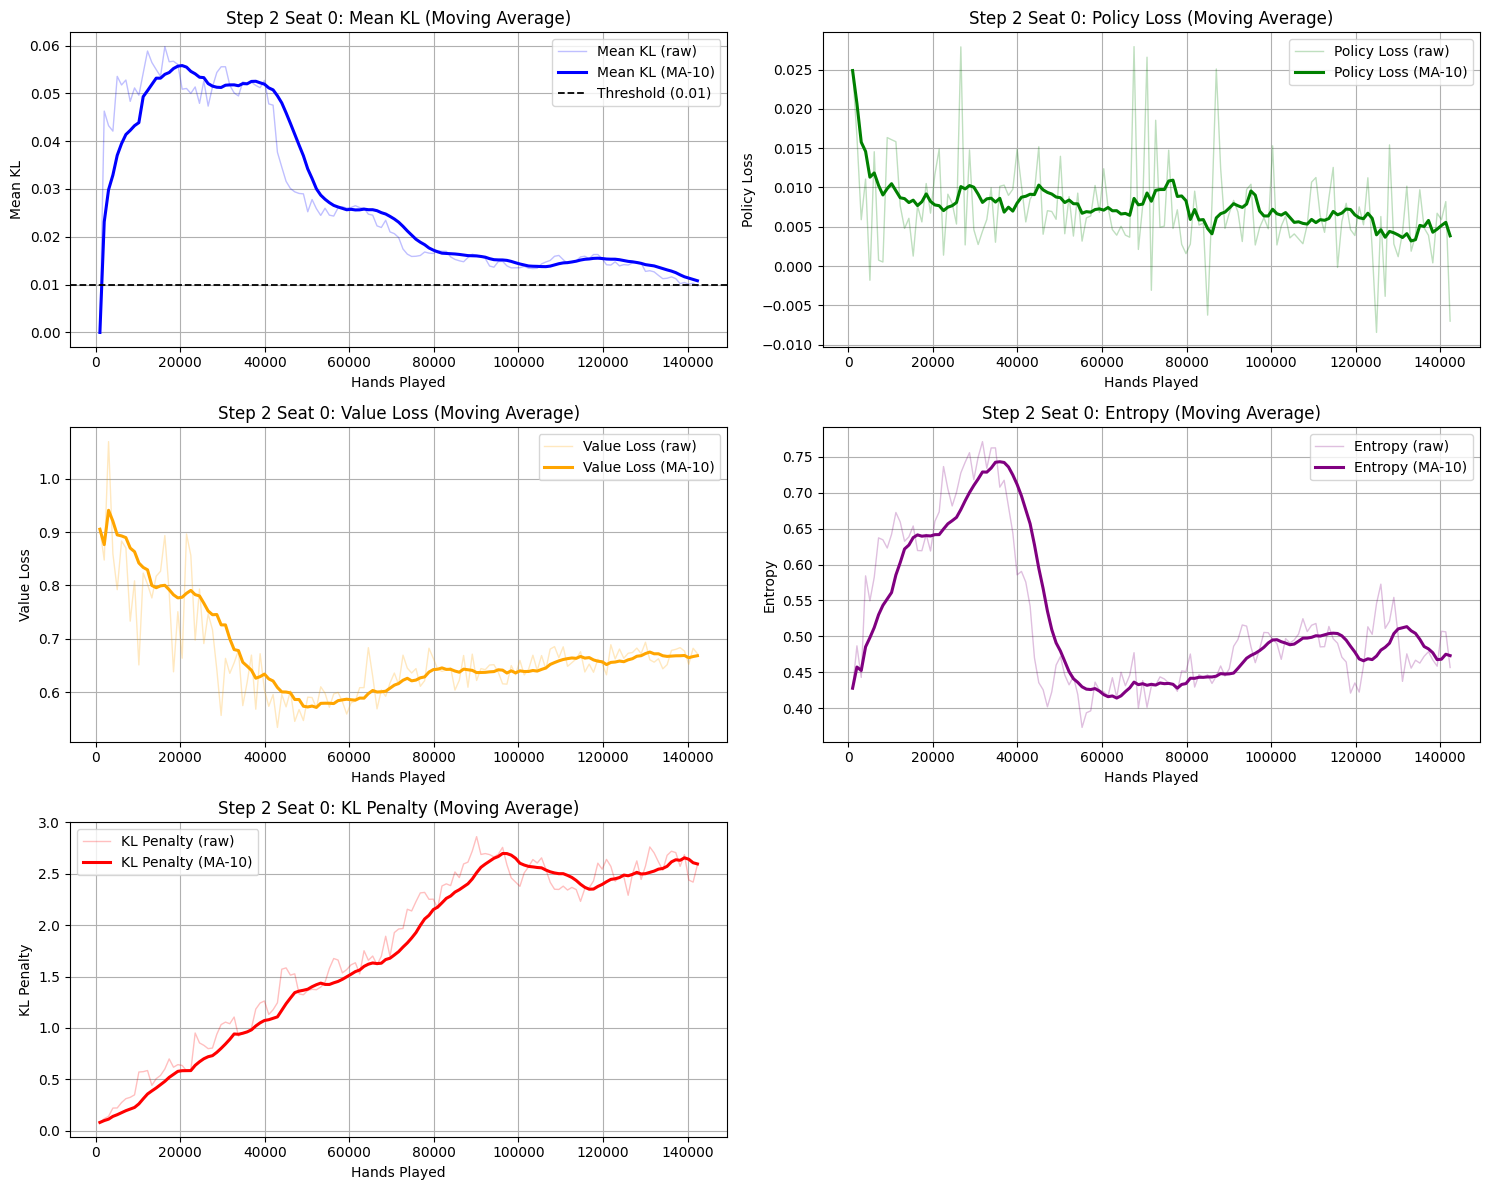

Plot for seat 0 saved to figs/step2_training_stats_seat_0_ma.png


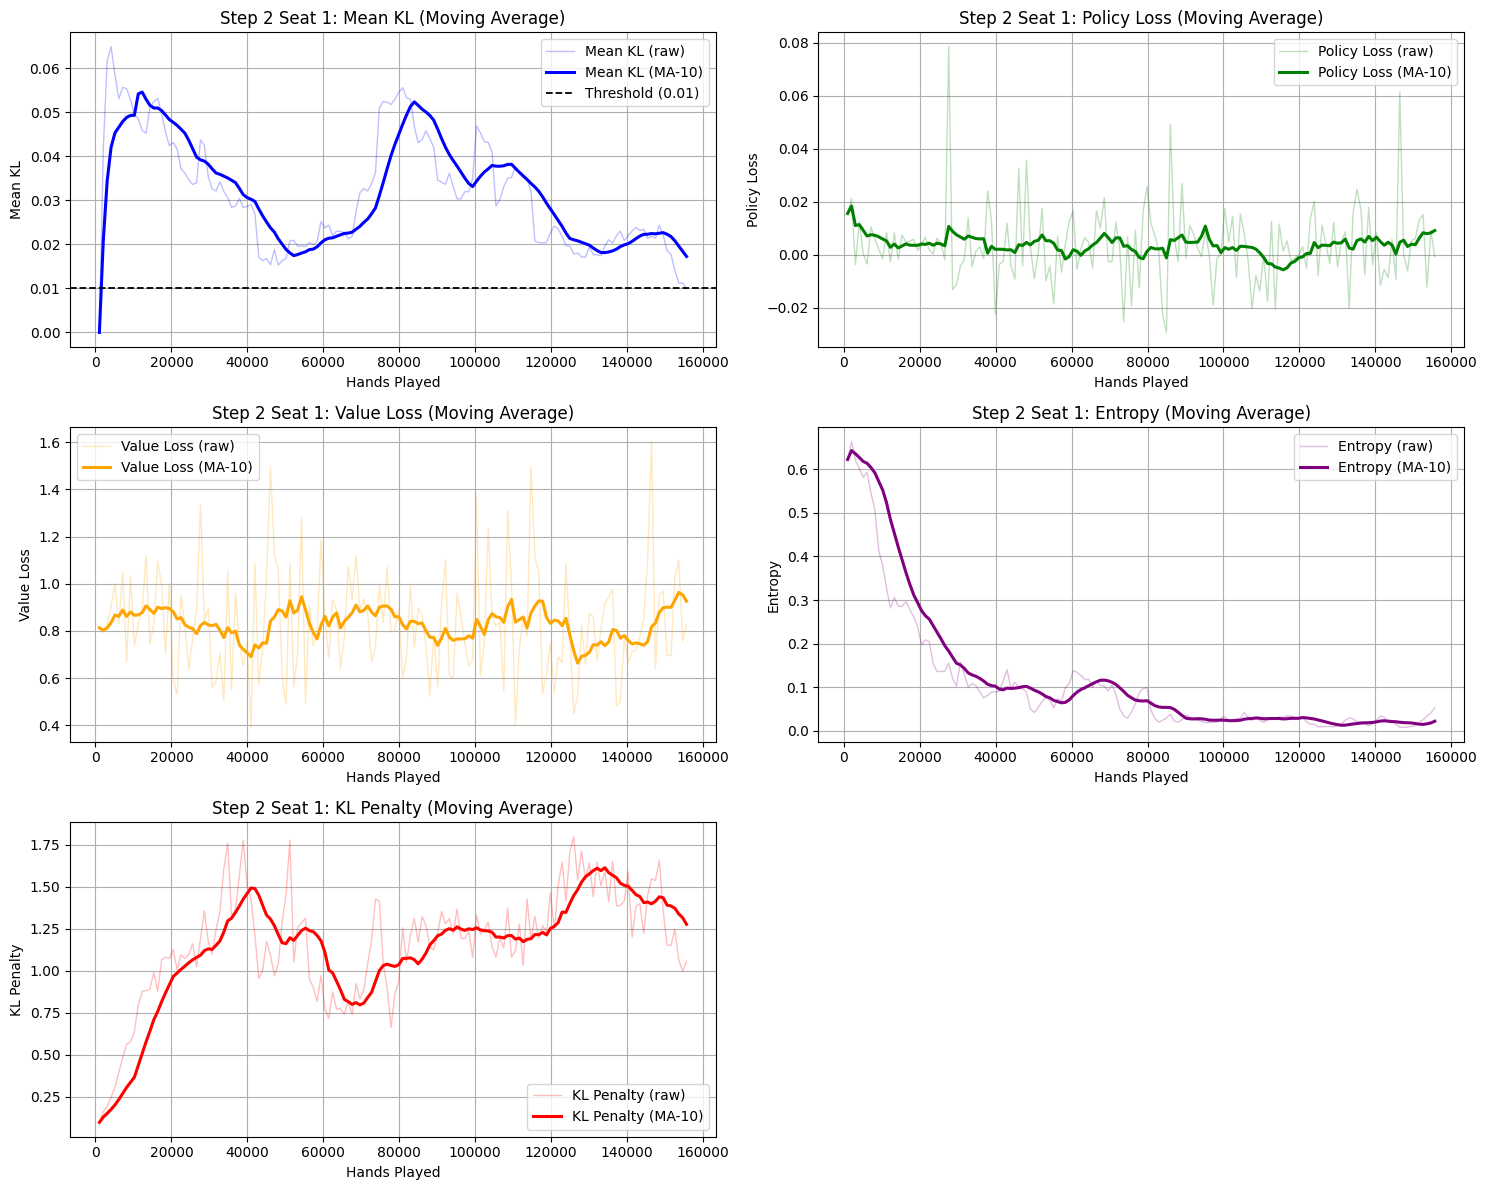

Plot for seat 1 saved to figs/step2_training_stats_seat_1_ma.png


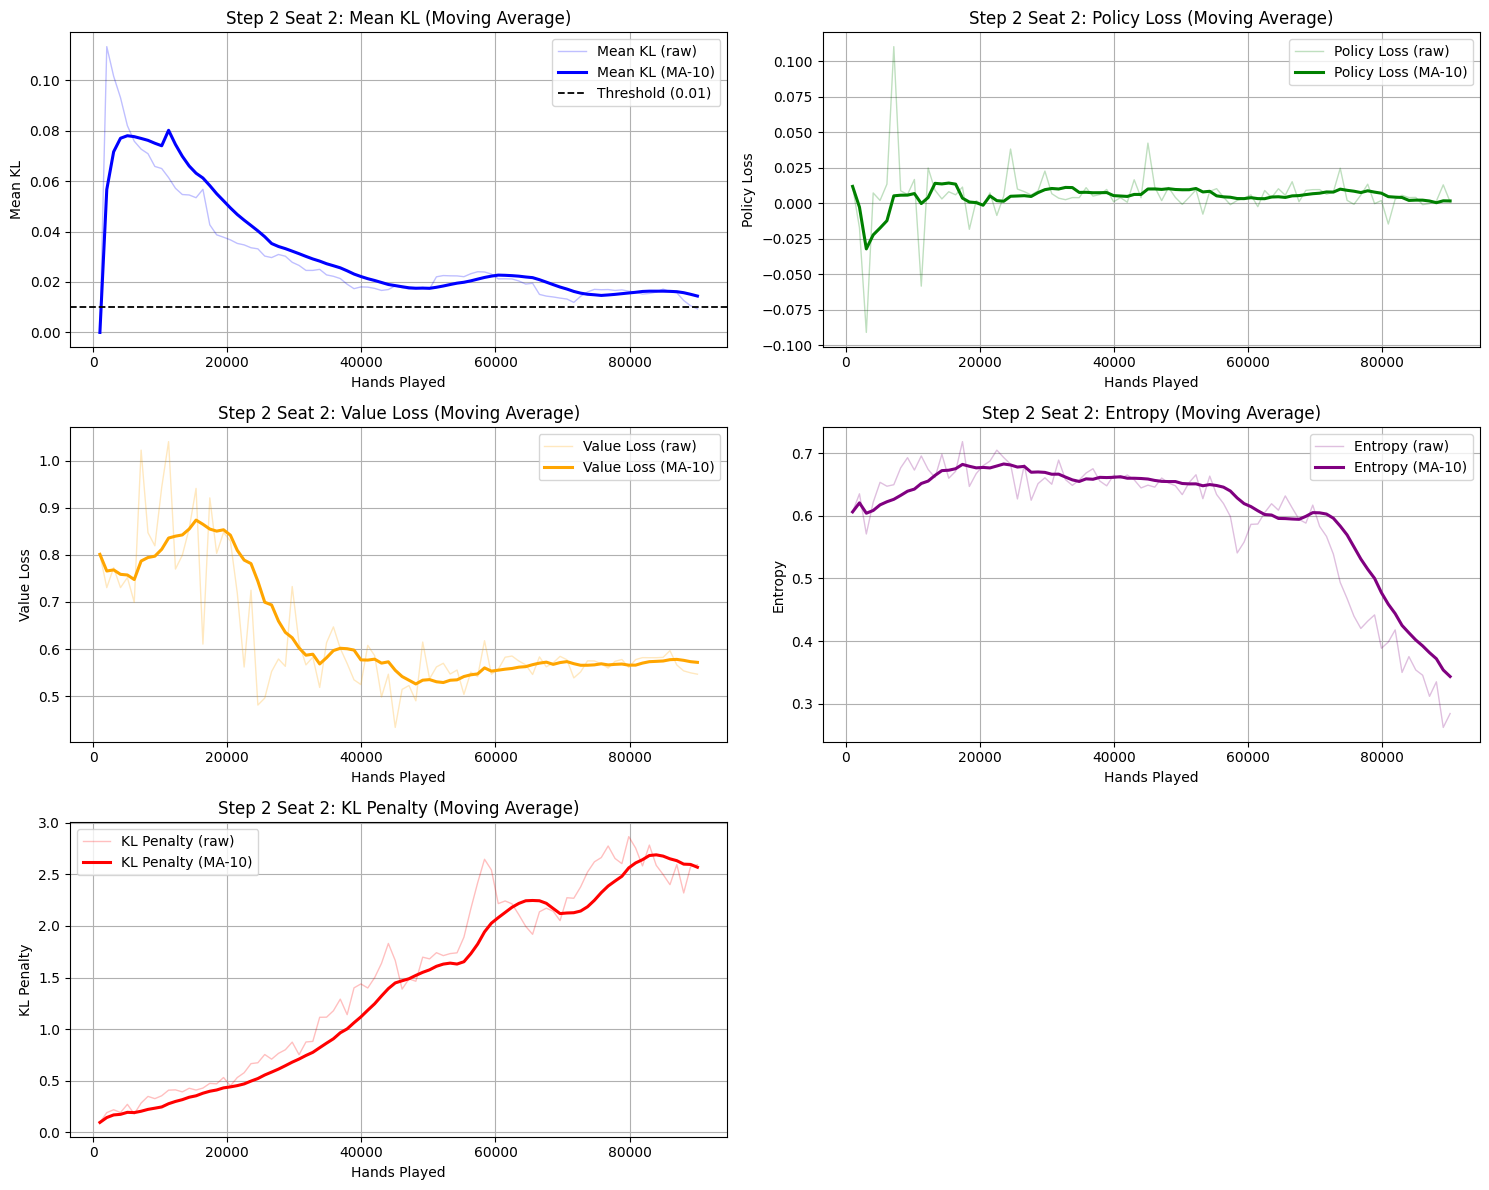

Plot for seat 2 saved to figs/step2_training_stats_seat_2_ma.png


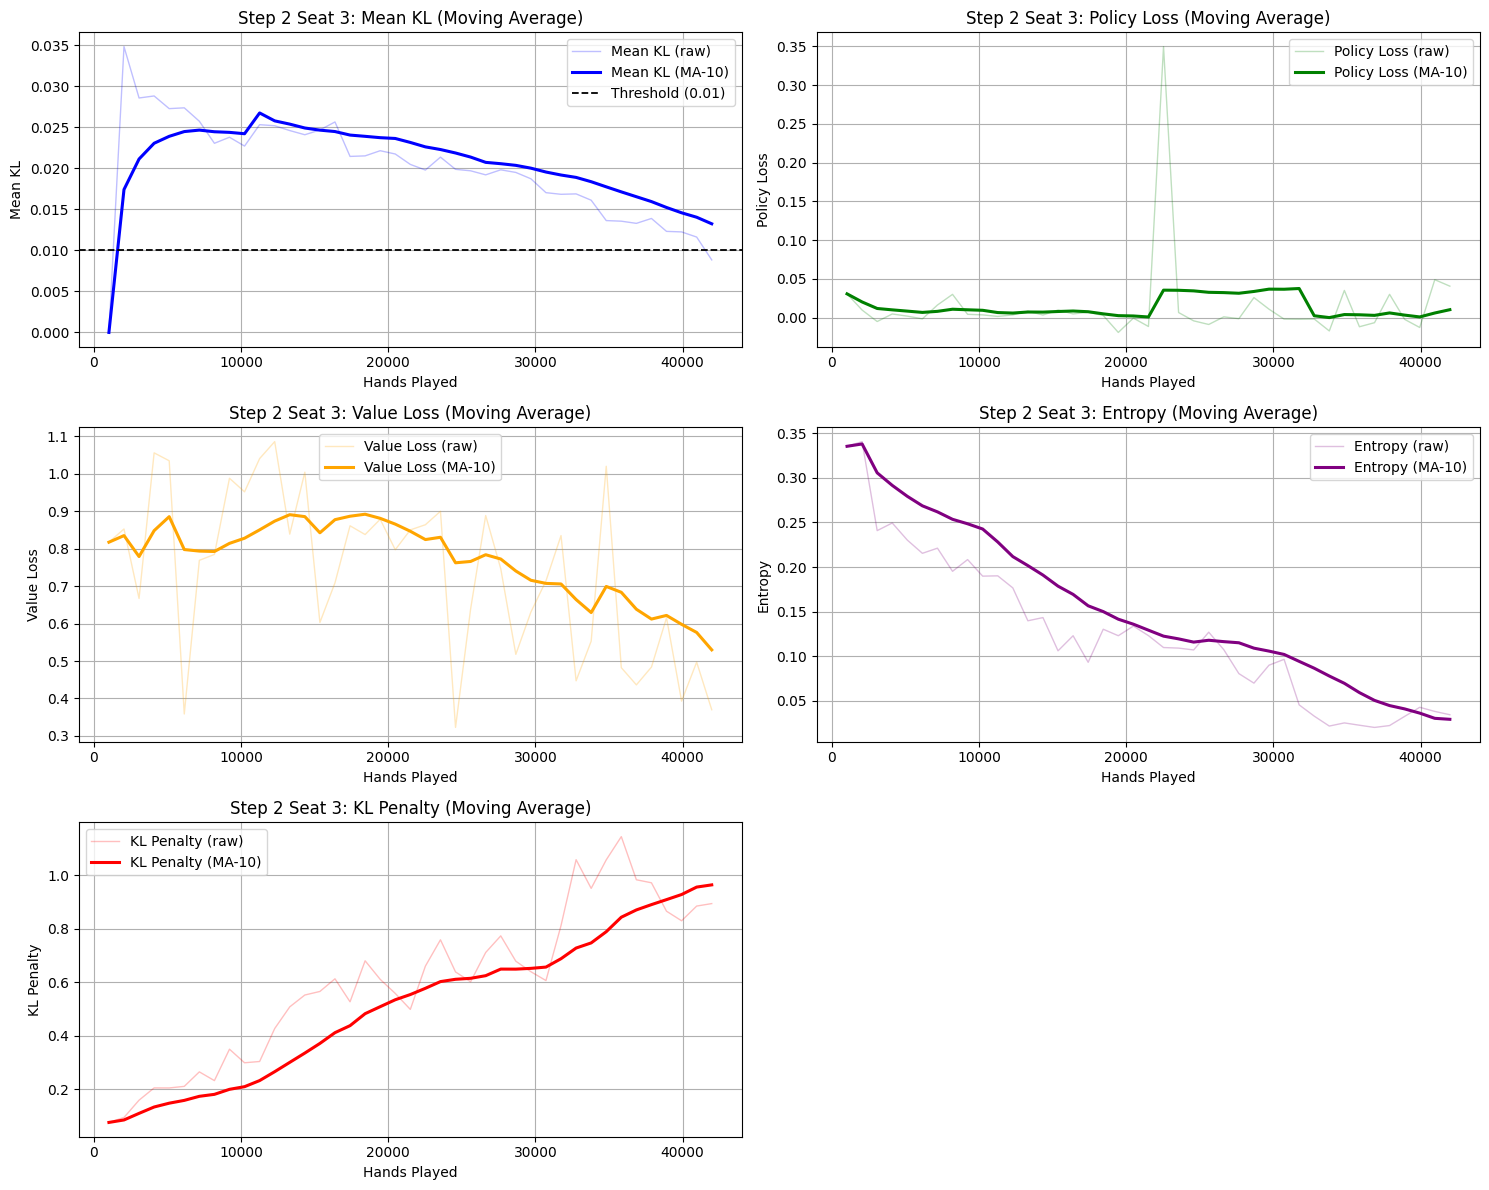

Plot for seat 3 saved to figs/step2_training_stats_seat_3_ma.png


In [ ]:
def plot_step2_stats(log_path, output_dir, ma_window=50, show_raw=True):
    if not os.path.exists(log_path):
        print(f"Log file not found at {log_path}")
        return

    with open(log_path, "r") as f:
        log_data = json.load(f)

    if not log_data:
        print("Log is empty.")
        return

    os.makedirs(output_dir, exist_ok=True)

    # Step 2 is seat-specific
    seats = sorted({entry["seat"] for entry in log_data})

    # Keep same core metrics as Step 1, plus Step 2-specific KL penalty
    # Step 2 threshold
    step2_threshold = 0.01
    if os.path.exists("code/step2_train_perturbed_agents.py"):
        with open("code/step2_train_perturbed_agents.py", "r") as f:
            for py_line in f:
                if py_line.startswith("CONV_THRESHOLD"):
                    try:
                        step2_threshold = float(py_line.split("=")[1].strip())
                    except:
                        pass

    stats = {
        "mean_kl":     {"label": "Mean KL",     "color": "blue",   "threshold": step2_threshold},
        "policy_loss": {"label": "Policy Loss", "color": "green"},
        "value_loss":  {"label": "Value Loss",  "color": "orange"},
        "entropy":     {"label": "Entropy",     "color": "purple"},
        "kl_penalty":  {"label": "KL Penalty",  "color": "red"},
    }

    for seat in seats:
        seat_data = [entry for entry in log_data if entry["seat"] == seat]
        hands = [entry["hand"] for entry in seat_data]

        # 3x2 grid for 5 metrics; hide one unused axis
        fig, axes = plt.subplots(3, 2, figsize=(15, 12))
        axes = axes.flatten()

        for i, (key, info) in enumerate(stats.items()):
            values = [entry[key] for entry in seat_data]
            ma_values = moving_average(values, ma_window)

            if show_raw:
                axes[i].plot(
                    hands, values,
                    color=info["color"],
                    alpha=0.25,
                    linewidth=1,
                    label=f"{info['label']} (raw)"
                )

            axes[i].plot(
                hands, ma_values,
                color=info["color"],
                linewidth=2.2,
                label=f"{info['label']} (MA-{ma_window})"
            )

            axes[i].set_xlabel("Hands Played")
            axes[i].set_ylabel(info["label"])
            axes[i].set_title(f"Step 2 Seat {seat}: {info['label']} (Moving Average)")
            axes[i].grid(True)

            if "threshold" in info:
                axes[i].axhline(
                    y=stats["mean_kl"]["threshold"],
                    color="black",
                    linestyle="--",
                    linewidth=1.3,
                    label=f"Threshold ({info['threshold']})"
                )

            axes[i].legend()

        # Hide unused subplot (6th slot)
        for j in range(len(stats), len(axes)):
            axes[j].axis("off")

        plt.tight_layout()
        output_path = os.path.join(output_dir, f"step2_training_stats_seat_{seat}_ma.png")
        plt.savefig(output_path, dpi=150)
        plt.show()
        plt.close(fig)
        print(f"Plot for seat {seat} saved to {output_path}")

if __name__ == "__main__":
    LOG_FILE = "checkpoints/perturbed_training_log.json"
    OUTPUT_DIR = "figs"
    plot_step2_stats(LOG_FILE, OUTPUT_DIR, ma_window=10, show_raw=True)

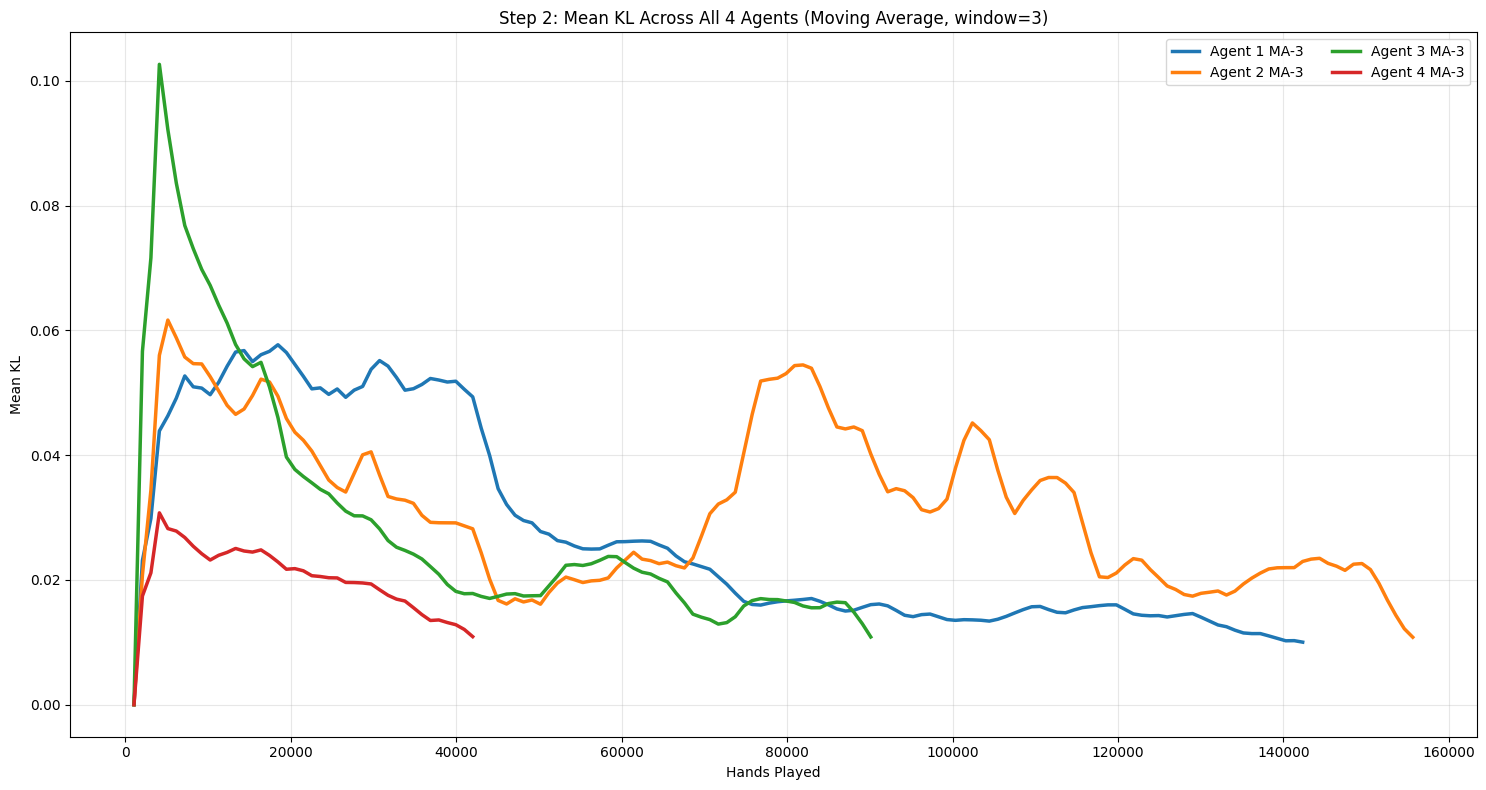

Plot saved to figs/step2_mean_kl_all_agents_ma.png


In [ ]:
def plot_mean_kl_all_agents(log_path, output_path, ma_window=50, show_raw=False):
    if not os.path.exists(log_path):
        print(f"Log file not found at {log_path}")
        return

    with open(log_path, "r") as f:
        log_data = json.load(f)

    if not log_data:
        print("Log is empty.")
        return

    seats = sorted({entry["seat"] for entry in log_data})
    colors = {
        seat: color for seat, color in zip(
            seats,
            ["tab:blue", "tab:orange", "tab:green", "tab:red"]
        )
    }

    plt.figure(figsize=(15, 8))

    for seat in seats:
        seat_data = [entry for entry in log_data if entry["seat"] == seat]
        hands = [entry["hand"] for entry in seat_data]
        values = [entry["mean_kl"] for entry in seat_data]
        ma_values = moving_average(values, ma_window)

        if show_raw:
            plt.plot(
                hands,
                values,
                color=colors.get(seat, "tab:blue"),
                alpha=0.18,
                linewidth=1,
                label=f"Agent {seat + 1} raw"
            )

        plt.plot(
            hands,
            ma_values,
            color=colors.get(seat, "tab:blue"),
            linewidth=2.5,
            label=f"Agent {seat + 1} MA-{ma_window}"
        )

    plt.xlabel("Hands Played")
    plt.ylabel("Mean KL")
    plt.title(f"Step 2: Mean KL Across All 4 Agents (Moving Average, window={ma_window})")
    plt.grid(True, alpha=0.3)
    plt.legend(ncol=2)
    plt.tight_layout()
    plt.savefig(output_path, dpi=150)
    plt.show()
    plt.close()
    print(f"Plot saved to {output_path}")

if __name__ == "__main__":
    LOG_FILE = "checkpoints/perturbed_training_log.json"
    OUTPUT_FILE = "figs/step2_mean_kl_all_agents_ma.png"
    plot_mean_kl_all_agents(LOG_FILE, OUTPUT_FILE, ma_window=3, show_raw=False)

In [ ]:
def create_irl_convergence_plot():
    log_path = 'irl_results/irl_convergence_log.json'
    if not os.path.exists(log_path):
        print(f"Error: {log_path} not found. Make sure step 3 has completed.")
        return

    # Try to load true params from checkpoints, otherwise use defaults from step 2
    params_path = 'checkpoints/perturbed_agent_params.json'
    true_alpha = {}
    true_beta = {}
    if os.path.exists(params_path):
        with open(params_path, 'r') as f:
            params = json.load(f)
            for p in params:
                true_alpha[p['seat']] = p['alpha']
                true_beta[p['seat']] = p['beta']
    else:
        # Fallback to the known defaults if the file isn't ready
        true_alpha = {0: 0.005, 1: 0.005, 2: -0.005, 3: -0.005}
        true_beta = {0: 0.3, 1: -0.3, 2: 0.3, 3: -0.3}

    with open(log_path, 'r') as f:
        log_data = json.load(f)

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
    
    colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728']
    
    for entry in log_data:
        seat = entry['seat']
        color = colors[seat % len(colors)]
        
        alpha_hist = entry.get('alpha_history', [])
        beta_hist = entry.get('beta_history', [])
        steps = list(range(len(alpha_hist)))
        
        # Plot estimated values
        ax1.plot(steps, alpha_hist, color=color, label=f'Seat {seat} Est')
        ax2.plot(steps, beta_hist, color=color, label=f'Seat {seat} Est')
        
        # Plot true values
        if seat in true_alpha:
            ax1.axhline(y=true_alpha[seat], color=color, linestyle='--', alpha=0.7)
        if seat in true_beta:
            ax2.axhline(y=true_beta[seat], color=color, linestyle='--', alpha=0.7)

    ax1.set_title(r'$\hat{\alpha}$ vs Gradient Step')
    ax1.set_xlabel('Gradient Step')
    ax1.set_ylabel(r'$\alpha$ value')
    ax1.grid(True, alpha=0.3)
    ax1.legend()

    ax2.set_title(r'$\hat{\beta}$ vs Gradient Step')
    ax2.set_xlabel('Gradient Step')
    ax2.set_ylabel(r'$\beta$ value')
    ax2.grid(True, alpha=0.3)
    ax2.legend()

    plt.tight_layout()
    os.makedirs('figs', exist_ok=True)
    out_path = 'figs/irl_convergence.png'
    plt.savefig(out_path, dpi=300, bbox_inches='tight')
    print(f"Successfully generated {out_path}")
    plt.close()

create_irl_convergence_plot()

Successfully generated figs/irl_convergence.png
